<a href="https://colab.research.google.com/github/xyt556/I-GUIDE-GeoAI-Education/blob/main/notebooks/13-foundation-models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 卫星嵌入

## 简介

传统的遥感工作流程将每个分析任务视为一个孤立的问题，需要为每个新项目单独标记数据、模型训练和验证。这种按任务处理的方法成本高昂、速度慢且难以扩展。

卫星嵌入提供了一种根本不同的方法。在大量卫星图像上预训练的基础模型将每个图像块或像素压缩成一个紧凑的数值向量（嵌入），该向量捕获光谱特征、空间纹理和土地覆盖特征等语义内容。一旦计算出来，嵌入就可以作为一种通用的表示形式，可重复用于许多任务而无需重新训练。

卫星嵌入数据集的生态系统发展迅速。像 [Clay](https://clay-foundation.github.io/model)、Major TOM、TESSERA 和 AlphaEarth 等项目已经发布了覆盖全球的预计算嵌入，分辨率从 10 米到 5 公里不等。本教程使用 `geoai` Python 包介绍卫星嵌入工作流程，涵盖三个系统：用于基于块的嵌入的 Clay 基础模型、用于基于像素的时间嵌入的 TESSERA 以及通过 Google Earth Engine 进行基于云分析的 AlphaEarth。

## 学习目标

通过本教程的学习，您将能够：

- 解释什么是卫星嵌入，并区分基于块和基于像素的格式
- 使用 `geoai` 浏览和查询可用嵌入数据集的注册表
- 从 Hugging Face 下载并加载 Clay 基础模型嵌入
- 使用主成分分析 (PCA) 可视化高维嵌入空间
- 聚类嵌入以发现没有标记数据的空间模式
- 执行相似性搜索以查找具有匹配特征的位置
- 在嵌入特征上训练轻量级分类器（k-NN、随机森林、逻辑回归）
- 比较不同位置的嵌入以进行变化检测
- 下载、可视化和采样 TESSERA 时间嵌入
- 在 Google Earth Engine 中探索 AlphaEarth 卫星嵌入以进行多年比较

## 什么是卫星嵌入？

卫星嵌入是一个固定长度的数值向量，它编码卫星图像块或像素的内容。基础模型通过深度神经网络处理原始图像来生成这些向量，从而创建一个高维空间，其中几何邻近性编码语义相似性。

卫星嵌入有两种格式。**基于块的嵌入**将整个图像块概括为一个向量，存储在 GeoParquet 文件中，适用于场景级任务，如检索和分类。**基于像素的嵌入**为 GeoTIFF 栅格中的每个像素分配一个向量，支持细粒度分析，如分割和逐像素分类。

`geoai` 包提供了来自多个基础模型的嵌入数据集的统一注册表，允许您列出、过滤和检索详细元数据。

In [4]:
%pip install -U "geoai-py[extra]"

In [3]:
import geoai
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub import HfApi, hf_hub_download

## 浏览可用的嵌入数据集

`geoai` 包提供了一个由 [TorchGeo](https://torchgeo.readthedocs.io) 数据集类支持的嵌入数据集注册表。使用 `list_embedding_datasets()` 查看可用内容。

In [4]:
df = geoai.list_embedding_datasets(verbose=False)
df

,name,class,kind,spatial_extent,resolution,temporal_extent,dimensions,dtype,license
0,clay,ClayEmbeddings,patch,Global*,5.12 km,2018-2023*,768,float32,ODC-By-1.0
1,major_tom,MajorTOMEmbeddings,patch,Global,2.14-3.56 km,2015-2024*,2048,float32,CC-BY-SA-4.0
2,earth_index,EarthIndexEmbeddings,patch,Global,320 m,2024,384,float32,CC-BY-4.0
3,earth_embeddings,EarthEmbeddings,patch,Global*,2.24-3.84 km,2015-2024*,256-1152,"float16, float32",CC-BY-SA-4.0
4,copernicus_embed,CopernicusEmbed,pixel,Global,0.25 deg,2021,768,float32,CC-BY-4.0
5,presto,PrestoEmbeddings,pixel,Togo,10 m,2019-2020,128,uint16,CC-BY-4.0
6,tessera,TesseraEmbeddings,pixel,Global,10 m,2017-2025*,128,int8 -> float32,CC0-1.0
7,google_satellite,GoogleSatelliteEmbedding,pixel,Global,10 m,2017-2025,64,int8 -> float64,CC-BY-4.0
8,embedded_seamless,EmbeddedSeamlessData,pixel,Global,30 m,2000-2024,12,uint16 -> float32,CC-BY-4.0


您可以按类型筛选，只查看基于块或基于像素的数据集。

In [5]:
geoai.list_embedding_datasets(kind="patch", verbose=False)

,name,class,kind,spatial_extent,resolution,temporal_extent,dimensions,dtype,license
0,clay,ClayEmbeddings,patch,Global*,5.12 km,2018-2023*,768,float32,ODC-By-1.0
1,major_tom,MajorTOMEmbeddings,patch,Global,2.14-3.56 km,2015-2024*,2048,float32,CC-BY-SA-4.0
2,earth_index,EarthIndexEmbeddings,patch,Global,320 m,2024,384,float32,CC-BY-4.0
3,earth_embeddings,EarthEmbeddings,patch,Global*,2.24-3.84 km,2015-2024*,256-1152,"float16, float32",CC-BY-SA-4.0


In [7]:
geoai.list_embedding_datasets(kind="pixel", verbose=False)

,name,class,kind,spatial_extent,resolution,temporal_extent,dimensions,dtype,license
0,copernicus_embed,CopernicusEmbed,pixel,Global,0.25 deg,2021,768,float32,CC-BY-4.0
1,presto,PrestoEmbeddings,pixel,Togo,10 m,2019-2020,128,uint16,CC-BY-4.0
2,tessera,TesseraEmbeddings,pixel,Global,10 m,2017-2025*,128,int8 -> float32,CC0-1.0
3,google_satellite,GoogleSatelliteEmbedding,pixel,Global,10 m,2017-2025,64,int8 -> float64,CC-BY-4.0
4,embedded_seamless,EmbeddedSeamlessData,pixel,Global,30 m,2000-2024,12,uint16 -> float32,CC-BY-4.0


使用 `get_embedding_info()` 详细检查特定数据集。

In [8]:
info = geoai.get_embedding_info("clay")
for key, value in info.items():
    print(f"{key}: {value}")

class_name: ClayEmbeddings
kind: patch
base: NonGeoDataset
spatial_extent: Global*
spatial_resolution: 5.12 km
temporal_extent: 2018-2023*
dimensions: 768
dtype: float32
license: ODC-By-1.0
description: Clay v0 and v1.5 embeddings from the Clay Foundation Model. Stored as GeoParquet files.
paper: https://clay-foundation.github.io/model/
data_source: https://source.coop/clay/clay-model-v0-embeddings


## 探索基于块的嵌入

基于块的嵌入将整个图像瓦片压缩成单个向量。Clay 基础模型从 Sentinel-2、Landsat、NAIP、Sentinel-1 和 MODIS 数据等来源生成 768 维嵌入。

我们将使用来自 [Hugging Face](https://huggingface.co/datasets/made-with-clay/classify-embeddings-sf-baseball-marinas) 的旧金山湾区 Clay 嵌入，其中包含来自 NAIP 图像的 768 维嵌入，涵盖 20 个瓦片，以及棒球场（类别 0）和码头（类别 1）的标记位置。

### 下载 Clay 嵌入

列出 Hugging Face 存储库中可用的 GeoParquet 文件。

In [9]:
repo_id = "made-with-clay/classify-embeddings-sf-baseball-marinas"

api = HfApi()
embedding_files = [
    f.path
    for f in api.list_repo_tree(repo_id, repo_type="dataset")
    if f.path.endswith(".gpq")
]
print(f"Found {len(embedding_files)} embedding tiles")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Found 20 embedding tiles


```text
找到 20 个嵌入瓦片
```

下载所有瓦片并将它们连接成一个 GeoDataFrame。

In [10]:
all_gdfs = []
for f in embedding_files:
    path = hf_hub_download(repo_id, f, repo_type="dataset")
    gdf = gpd.read_parquet(path)
    all_gdfs.append(gdf)

embeddings_gdf = pd.concat(all_gdfs, ignore_index=True)
embeddings_gdf = gpd.GeoDataFrame(
    embeddings_gdf, geometry="geometry", crs=all_gdfs[0].crs
)
print(f"Combined: {len(embeddings_gdf)} patches")
print(f"Bounds: {embeddings_gdf.total_bounds}")
print(f"Embedding dimension: {len(embeddings_gdf.iloc[0]['embeddings'])}")

embeddings_ca_m_3712212_ne_10_060_202205(…):   0%|          | 0.00/5.76M [00:00<?, ?B/s]

embeddings_ca_m_3712212_nw_10_060_202205(…):   0%|          | 0.00/5.76M [00:00<?, ?B/s]

embeddings_ca_m_3712212_se_10_060_202205(…):   0%|          | 0.00/5.76M [00:00<?, ?B/s]

embeddings_ca_m_3712213_ne_10_060_202205(…):   0%|          | 0.00/5.87M [00:00<?, ?B/s]

embeddings_ca_m_3712213_nw_10_060_202205(…):   0%|          | 0.00/5.76M [00:00<?, ?B/s]

...

embeddings_ca_m_3712228_ne_10_060_202205(…):   0%|          | 0.00/5.76M [00:00<?, ?B/s]

embeddings_ca_m_3712229_ne_10_060_202205(…):   0%|          | 0.00/5.87M [00:00<?, ?B/s]

embeddings_ca_m_3712229_nw_10_060_202205(…):   0%|          | 0.00/5.76M [00:00<?, ?B/s]

embeddings_ca_m_3712230_nw_10_060_202205(…):   0%|          | 0.00/5.87M [00:00<?, ?B/s]

Combined: 36024 patches
Bounds: [-122.62763615   37.56033178 -122.3108981    37.87715656]
Embedding dimension: 768


```text
合并：36024 个块
边界：[-122.62763615   37.56033178 -122.3108981    37.87715656]
嵌入维度：768
```

下载两个类别的标记点位置：棒球场（类别 0）和码头（类别 1）。

In [11]:
labels_file = hf_hub_download(repo_id, "baseball.geojson", repo_type="dataset")
labels_gdf = gpd.read_file(labels_file)
print(f"Labeled locations: {len(labels_gdf)}")
print(f"Class distribution:")
print(labels_gdf["class"].value_counts())

baseball.geojson:   0%|          | 0.00/14.4k [00:00<?, ?B/s]

Labeled locations: 97
Class distribution:
class
0    74
1    23
Name: count, dtype: int64


```text
标记位置：97
类别分布：
类别
0    74
1    23
名称：count，数据类型：int64
```

### 提取嵌入向量

将嵌入向量堆叠成 NumPy 矩阵，并提取质心坐标以进行地理绘图。

In [12]:
embeddings = np.stack(embeddings_gdf["embeddings"].values)
centroids = embeddings_gdf.geometry.centroid
coords_x = centroids.x.values
coords_y = centroids.y.values

print(f"Embeddings shape: {embeddings.shape}")
print(f"X range: [{coords_x.min():.4f}, {coords_x.max():.4f}]")
print(f"Y range: [{coords_y.min():.4f}, {coords_y.max():.4f}]")

Embeddings shape: (36024, 768)
X range: [-122.6268, -122.3118]
Y range: [37.5610, 37.8765]


/tmp/ipykernel_3442/3157486340.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = embeddings_gdf.geometry.centroid


```text
嵌入形状：(36024, 768)
X 范围：[-122.6268, -122.3118]
Y 范围：[37.5610, 37.8765]
```

## 可视化嵌入

PCA（主成分分析）将高维嵌入投影到二维空间，同时保留重要的结构关系。绘制一些单独的嵌入向量以查看它们在 768 个维度上的原始模式。

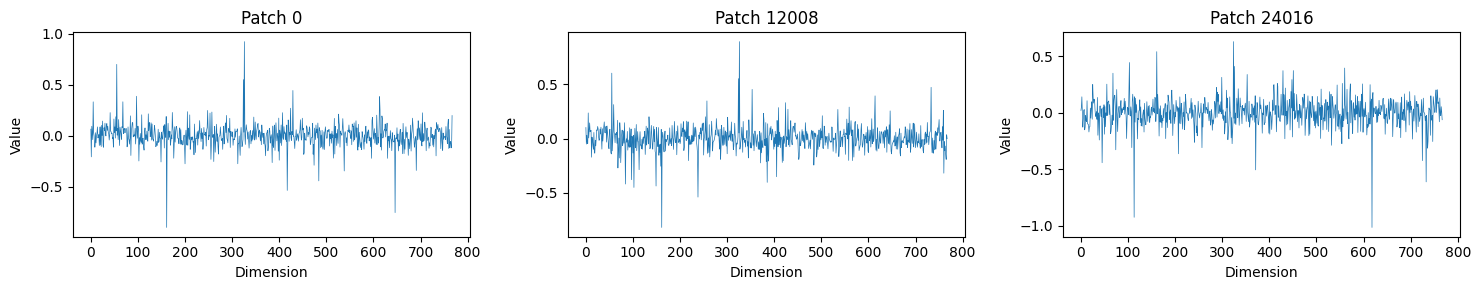

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for i, ax in enumerate(axes):
    idx = i * (len(embeddings) // 3)
    ax.plot(embeddings[idx], linewidth=0.5)
    ax.set_title(f"Patch {idx}")
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

将所有嵌入投影到二维 PCA 散点图中。

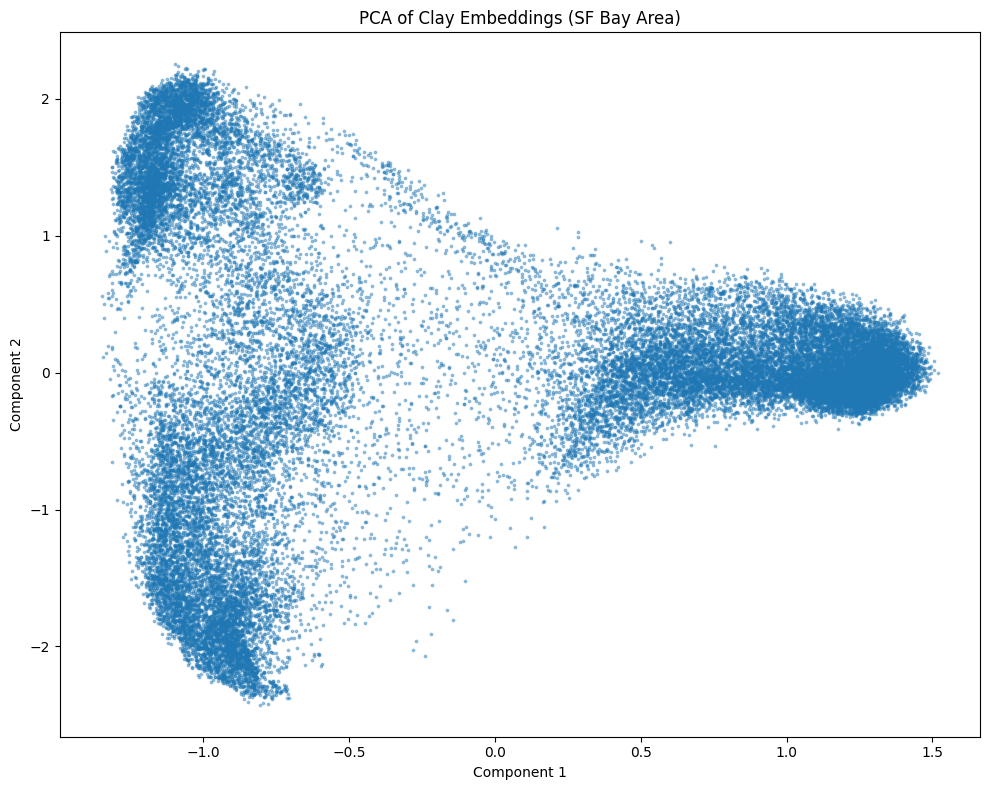

In [14]:
fig = geoai.visualize_embeddings(
    embeddings,
    method="pca",
    figsize=(10, 8),
    s=3,
    alpha=0.4,
    title="PCA of Clay Embeddings (SF Bay Area)",
)
plt.show()

彼此靠近的点代表具有相似视觉和光谱特征的瓦片，不同的簇通常对应于不同的土地覆盖类型。

## 聚类嵌入

聚类根据嵌入空间中的邻近性将嵌入分组为离散类别，无需标记数据。`cluster_embeddings()` 函数支持 K 均值聚类。

In [15]:
result = geoai.cluster_embeddings(embeddings, n_clusters=8, method="kmeans")
cluster_labels = result["labels"]
print(f"Number of clusters: {result['n_clusters']}")
print(f"Cluster sizes: {np.bincount(cluster_labels)}")

Number of clusters: 8
Cluster sizes: [4284 5424 7097 5556 4136 3952 2936 2639]


```text
簇数量：8
簇大小：[4284 5424 7097 5556 4136 3952 2936 2639]
```

通过使用聚类分配对 PCA 嵌入图进行着色来可视化聚类。

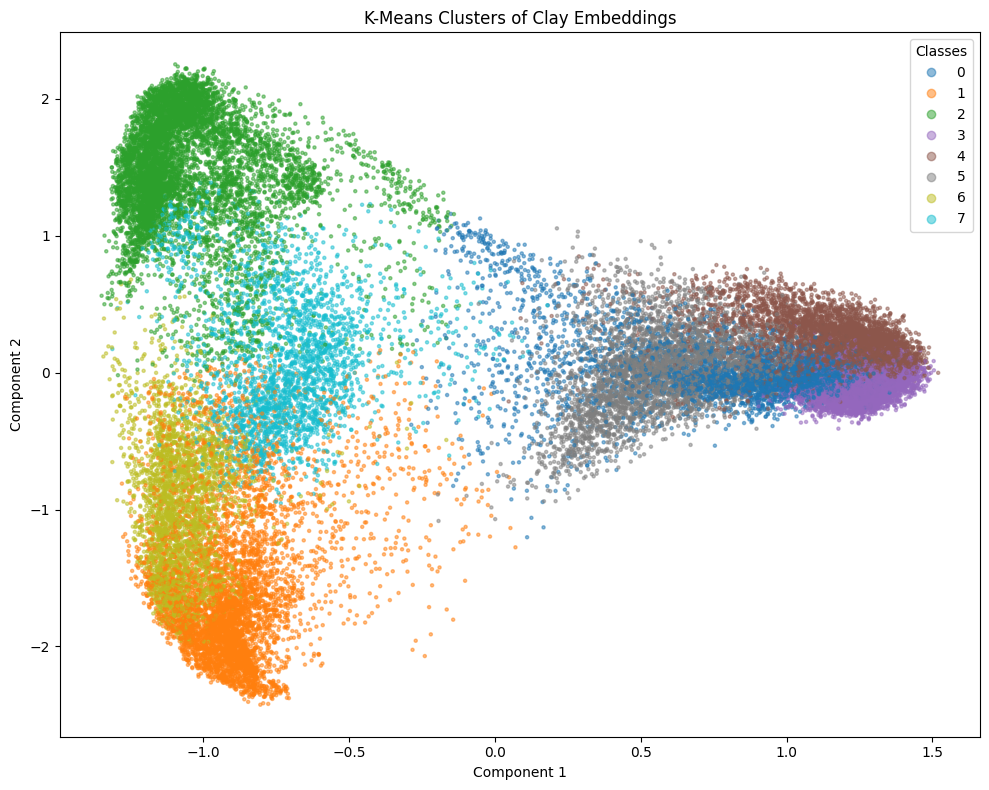

In [16]:
fig = geoai.visualize_embeddings(
    embeddings,
    labels=cluster_labels,
    method="pca",
    figsize=(10, 8),
    s=5,
    alpha=0.5,
    title="K-Means Clusters of Clay Embeddings",
)
plt.show()

将聚类分配地理映射，以查看它们如何与空间模式对应。

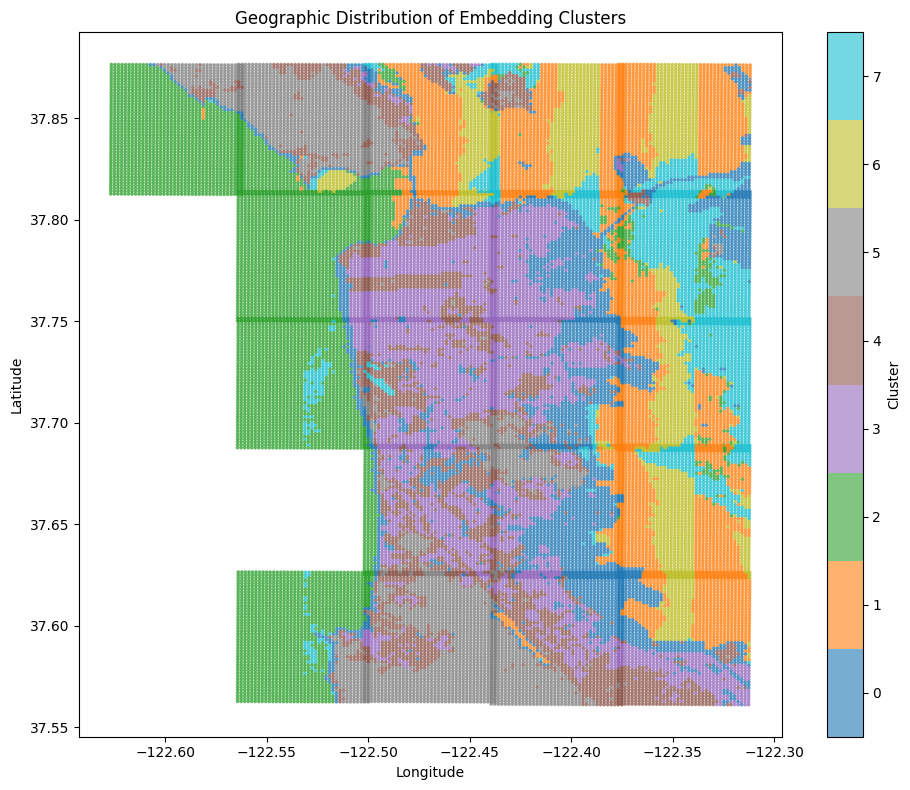

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
n_clusters = len(set(cluster_labels))
scatter = ax.scatter(
    coords_x,
    coords_y,
    c=cluster_labels,
    cmap=plt.colormaps["tab10"].resampled(n_clusters),
    vmin=-0.5,
    vmax=n_clusters - 0.5,
    s=3,
    alpha=0.6,
)
plt.colorbar(scatter, ax=ax, label="Cluster", ticks=range(n_clusters))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution of Embedding Clusters")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

检查聚类的地理分布可以揭示城市与植被区域等空间模式，这些模式是在没有任何人为定义的类别的情况下自然形成的。

## 相似性搜索

相似性搜索可以找到嵌入与查询最相似的位置，这对于灾害响应、生态监测和城市规划非常有用。`embedding_similarity()` 函数计算查询与所有其他嵌入之间的成对余弦相似度分数。

In [18]:
query_idx = 0
query = embeddings[query_idx]
print(
    f"Query location (lat, lon): ({coords_y[query_idx]:.4f}, {coords_x[query_idx]:.4f})"
)

results = geoai.embedding_similarity(
    query=query, embeddings=embeddings, metric="cosine", top_k=10
)

print("\nTop 10 most similar locations:")
for rank, (idx, score) in enumerate(
    zip(results["indices"], results["scores"]), start=1
):
    print(
        f"  {rank}. Index {idx}: similarity={score:.4f}, "
        f"location=({coords_y[idx]:.4f}, {coords_x[idx]:.4f})"
    )

Query location (lat, lon): (37.8764, -122.5639)

Top 10 most similar locations:
  1. Index 0: similarity=1.0000, location=(37.8764, -122.5639)
  2. Index 1822: similarity=0.9521, location=(37.8761, -122.5636)
  3. Index 1935: similarity=0.8796, location=(37.8720, -122.5653)
  4. Index 1860: similarity=0.8707, location=(37.8747, -122.5636)
  5. Index 38: similarity=0.8695, location=(37.8750, -122.5639)
  6. Index 1892: similarity=0.8582, location=(37.8734, -122.5741)
  7. Index 1820: similarity=0.8579, location=(37.8761, -122.5671)
  8. Index 450: similarity=0.8561, location=(37.8609, -122.5081)
  9. Index 606: similarity=0.8520, location=(37.8554, -122.5011)
  10. Index 1852: similarity=0.8385, location=(37.8748, -122.5775)


```text
查询位置（纬度，经度）：(37.8764, -122.5639)

前 10 个最相似的位置：
  1. 索引 0：相似度=1.0000，位置=(37.8764, -122.5639)
  2. 索引 1822：相似度=0.9521，位置=(37.8761, -122.5636)
  3. 索引 1935：相似度=0.8796，位置=(37.8720, -122.5653)
  4. 索引 1860：相似度=0.8707，位置=(37.8747, -122.5636)
  5. 索引 38：相似度=0.8695，位置=(37.8750, -122.5639)
  6. 索引 1892：相似度=0.8582，位置=(37.8734, -122.5741)
  7. 索引 1820：相似度=0.8579，位置=(37.8761, -122.5671)
  8. 索引 450：相似度=0.8561，位置=(37.8609, -122.5081)
  9. 索引 606：相似度=0.8520，位置=(37.8554, -122.5011)
  10. 索引 1852：相似度=0.8385，位置=(37.8748, -122.5775)
```

在地理图上可视化查询点及其最近邻居。

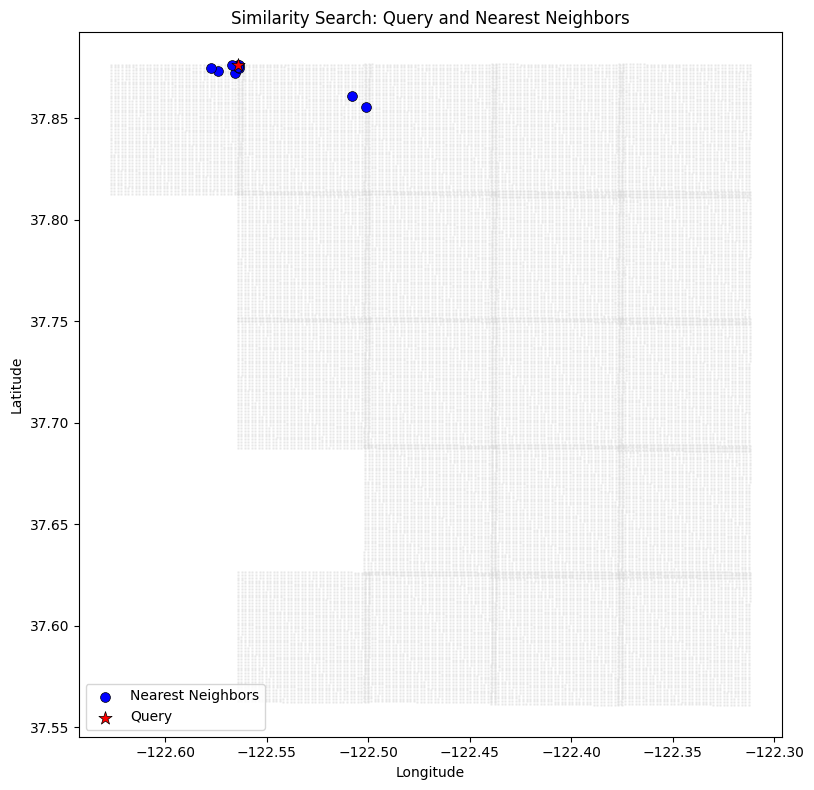

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

# Background: all embeddings in gray
ax.scatter(coords_x, coords_y, c="lightgray", s=1, alpha=0.3)

# Highlight nearest neighbors
nn_indices = results["indices"]
ax.scatter(
    coords_x[nn_indices],
    coords_y[nn_indices],
    c="blue",
    s=50,
    marker="o",
    label="Nearest Neighbors",
    edgecolors="black",
    linewidths=0.5,
)

# Highlight the query point
ax.scatter(
    coords_x[query_idx],
    coords_y[query_idx],
    c="red",
    s=100,
    marker="*",
    label="Query",
    edgecolors="black",
    linewidths=0.5,
    zorder=5,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Similarity Search: Query and Nearest Neighbors")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

得分为 1.0 意味着嵌入完全相同，而较低的得分表示相似度降低。地理图显示了相似嵌入是否在空间上聚集。

## 在嵌入上训练分类器

由于基础模型已经提取了丰富的特征，因此只需要一个简单的分类器。工作流程包括通过空间连接将标记点与嵌入块匹配，然后将其分为训练集和验证集。

In [20]:
# Ensure both GeoDataFrames use the same CRS
if labels_gdf.crs != embeddings_gdf.crs:
    labels_gdf = labels_gdf.to_crs(embeddings_gdf.crs)

# Spatial join: find which embedding patch each labeled point falls within
joined = gpd.sjoin(labels_gdf, embeddings_gdf, how="inner", predicate="within")
print(f"Matched {len(joined)} labeled points to embedding patches")
print(f"Class distribution: {joined['class'].value_counts().to_dict()}")

Matched 106 labeled points to embedding patches
Class distribution: {0: 79, 1: 27}


```text
匹配到 106 个标记点到嵌入块
类别分布：{0: 79, 1: 27}
```

提取每个匹配点的嵌入向量。

In [21]:
labeled_embeddings = np.stack(
    [embeddings_gdf.iloc[idx]["embeddings"] for idx in joined["index_right"]]
)
class_labels = joined["class"].values

print(f"Labeled embeddings shape: {labeled_embeddings.shape}")
print(f"Labels shape: {class_labels.shape}")

Labeled embeddings shape: (106, 768)
Labels shape: (106,)


```text
标记嵌入形状：(106, 768)
标签形状：(106,)
```

按 70% 训练和 30% 验证进行分层抽样。

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    labeled_embeddings,
    class_labels,
    test_size=0.3,
    random_state=42,
    stratify=class_labels,
)
print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")

Train: 74 samples
Val:   32 samples


```text
训练：74 个样本
验证：32 个样本
```

训练 k-NN 分类器。

In [23]:
label_names = ["Baseball Field", "Marina"]

result = geoai.train_embedding_classifier(
    train_embeddings=X_train,
    train_labels=y_train,
    val_embeddings=X_val,
    val_labels=y_val,
    method="knn",
    n_neighbors=5,
    label_names=label_names,
)

print(f"\nTrain accuracy: {result['train_accuracy']:.2%}")
print(f"Val accuracy:   {result['val_accuracy']:.2%}")


Train accuracy: 86.49%
Val accuracy:   75.00%


```text
              precision    recall  f1-score   support

Baseball Field      0.864     0.792     0.826        24
        Marina      0.500     0.625     0.556         8

      accuracy                          0.750        32
     macro avg      0.682     0.708     0.691        32
  weighted avg      0.773     0.750     0.758        32

训练准确度：86.49%
验证准确度：75.00%
```

比较三种分类器方法。

In [24]:
methods = ["knn", "random_forest", "logistic_regression"]
results_summary = []

for method in methods:
    res = geoai.train_embedding_classifier(
        train_embeddings=X_train,
        train_labels=y_train,
        val_embeddings=X_val,
        val_labels=y_val,
        method=method,
        label_names=label_names,
        verbose=False,
    )
    results_summary.append(
        {
            "Method": method,
            "Train Acc": f"{res['train_accuracy']:.2%}",
            "Val Acc": f"{res['val_accuracy']:.2%}",
        }
    )

pd.DataFrame(results_summary)

,Method,Train Acc,Val Acc
0,knn,86.49%,75.00%
1,random_forest,100.00%,75.00%
2,logistic_regression,95.95%,75.00%


在 PCA 空间中可视化标记的嵌入，以查看两个类别分离得如何。

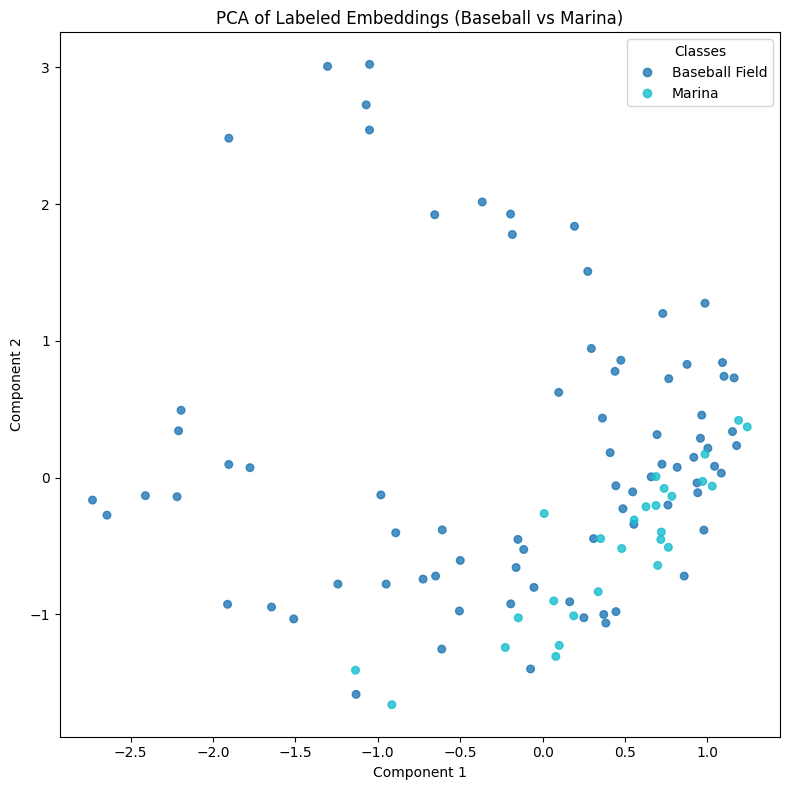

In [25]:
fig = geoai.visualize_embeddings(
    labeled_embeddings,
    labels=class_labels,
    label_names=label_names,
    method="pca",
    figsize=(8, 8),
    s=30,
    alpha=0.8,
    title="PCA of Labeled Embeddings (Baseball vs Marina)",
)
plt.show()

基础模型承担了特征提取的繁重工作，下游分类器只需几秒钟即可训练，且标记样本极少。

## 比较嵌入以进行变化检测

比较同一位置在不同时间段的嵌入可以揭示景观变化。`compare_embeddings()` 函数量化相似性，其中较高的余弦值表示稳定性，较低的值表示变化。

我们通过比较不同空间块的嵌入来演示。

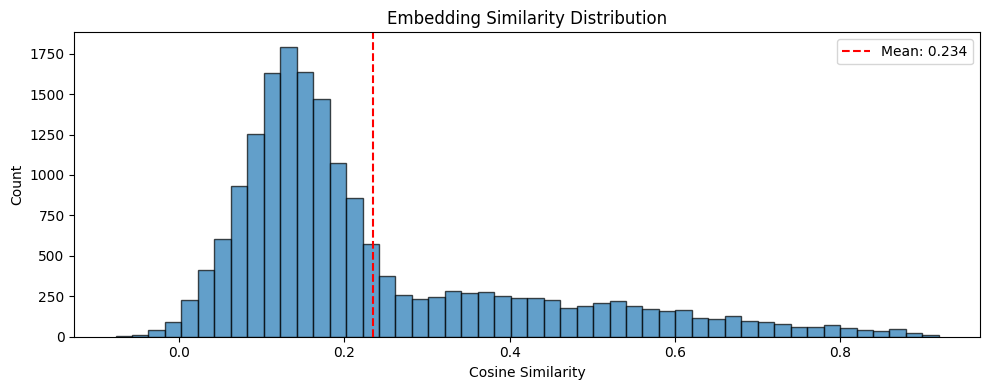

In [26]:
n = len(embeddings)
half = n // 2
emb_a = embeddings[:half]
emb_b = embeddings[half : half + half]

similarity = geoai.compare_embeddings(emb_a, emb_b, metric="cosine")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarity, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(
    similarity.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {similarity.mean():.3f}",
)
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.set_title("Embedding Similarity Distribution")
ax.legend()
plt.tight_layout()
plt.show()

在真实的时间比较中，您将比较不同日期同一位置的嵌入，低相似度异常值将指示显著变化的区域。

## 使用 TorchGeo 加载数据集

对于高级用法，直接通过 `geoai.load_embedding_dataset()` 加载 TorchGeo 数据集类，以访问转换、采样和内置绘图。

请注意，TorchGeo 的 `ClayEmbeddings` 类需要 GeoParquet 文件中包含 `date` 或 `datetime` 列。某些文件可能不包含此列，因此需要回退到 geopandas。

In [27]:
single_file = hf_hub_download(repo_id, embedding_files[0], repo_type="dataset")
ds = geoai.load_embedding_dataset("clay", root=single_file)

print(f"Dataset length: {len(ds)}")
print(f"Dataset type: {type(ds).__name__}")

Dataset length: 1786
Dataset type: ClayEmbeddings


```text
数据集长度：1786
数据集类型：ClayEmbeddings
```

In [28]:
try:
    sample = ds[0]
    print(f"Sample keys: {list(sample.keys())}")
    print(f"Embedding shape: {sample['embedding'].shape}")

    fig = ds.plot(sample)
    plt.show()
except KeyError as e:
    print(
        f"Note: This parquet file is missing the '{e.args[0]}' column "
        f"expected by TorchGeo's ClayEmbeddings class."
    )
    print("For such files, use geopandas directly (as shown above).")
    print("The TorchGeo class works best with official Clay data products.")

Note: This parquet file is missing the 'datetime' column expected by TorchGeo's ClayEmbeddings class.
For such files, use geopandas directly (as shown above).
The TorchGeo class works best with official Clay data products.


## 使用 TESSERA 时间嵌入

[TESSERA](https://github.com/ucam-eo/tessera)（地表光谱时间嵌入表示和分析）从时间序列 Sentinel-1 和 Sentinel-2 图像生成全球范围内的 10 米分辨率 128 通道表示图。`geoai` 包包括用于检查可用性、下载、可视化和采样 TESSERA 嵌入的函数。

In [2]:
%pip install "geoai-py[extra]" geotessera

### 检查数据可用性

检查哪些年份可用以及有多少瓦片覆盖您的区域。

In [6]:
import geoai
years = geoai.tessera_available_years()
print(f"Available years: {years}")

Available years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


```text
可用年份：[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
```

定义剑桥（英国）的边界框并检查瓦片计数。

In [7]:
bbox = (0.05, 52.15, 0.25, 52.25)
count = geoai.tessera_tile_count(bbox=bbox, year=2024)
print(f"{count} tiles available for the specified region")

6 tiles available for the specified region


```text
指定区域有 6 个瓦片可用
```

生成覆盖图。

In [ ]:
geoai.tessera_coverage(year=2024, output_path="tessera_coverage_2024.png")

In [ ]:
geoai.tessera_coverage(
    year=2024, region_bbox=(-10, 35, 40, 60), output_path="tessera_coverage_europe.png"
)

### 下载嵌入

TESSERA 嵌入可以按边界框、点坐标或 GeoTIFF 或 NumPy 格式的区域文件下载。

In [ ]:
bbox = (0.05, 52.15, 0.25, 52.25)

cambridge_files = geoai.tessera_download(
    bbox=bbox, year=2024, output_dir="./tessera_cambridge", output_format="tiff"
)
print(f"Downloaded {len(cambridge_files)} files")
for f in cambridge_files:
    print(f"  {f}")

按点坐标下载单个瓦片。

In [ ]:
files = geoai.tessera_download(
    lon=0.15, lat=52.05, year=2024, output_dir="./tessera_single_tile"
)
print(f"Downloaded {len(files)} file(s)")

仅下载特定波段以减少文件大小。

In [ ]:
files = geoai.tessera_download(
    bbox=bbox, year=2024, bands=[0, 1, 2], output_dir="./tessera_rgb_only"
)
print(f"Downloaded {len(files)} files with 3 bands each")

### 可视化 TESSERA 嵌入

TESSERA 嵌入可以通过选择 128 个通道中的三个来渲染为伪彩色 RGB 合成图。颜色相似的区域具有相似的时间动态。

In [ ]:
geoai.tessera_visualize_rgb(
    str(cambridge_files[0]), bands=(0, 1, 2), title="Cambridge - TESSERA Bands 0, 1, 2"
)

尝试不同的波段组合以突出时间信号的其他方面。

In [ ]:
geoai.tessera_visualize_rgb(
    str(cambridge_files[0]),
    bands=(30, 60, 90),
    title="Cambridge - TESSERA Bands 30, 60, 90",
)

不同的波段组合可以揭示季节性植被模式、城市热特征或水体动态。

### 将嵌入获取到内存中

使用 `tessera_fetch_embeddings()` 将嵌入数组直接加载到内存中，而无需将文件保存到磁盘。

In [ ]:
tiles = geoai.tessera_fetch_embeddings(bbox=(0.05, 52.15, 0.25, 52.25), year=2024)

for tile in tiles:
    print(f"Tile ({tile['lon']:.2f}, {tile['lat']:.2f}):")
    print(f"  Shape: {tile['embedding'].shape}")
    print(f"  CRS: {tile['crs']}")
    print(f"  Mean: {tile['embedding'].mean():.4f}")
    print(f"  Std: {tile['embedding'].std():.4f}")

### 在点位置采样嵌入

使用 `tessera_sample_points()` 提取特定点的嵌入值，该函数将 128 列（`tessera_0` 到 `tessera_127`）附加到输入的 GeoDataFrame。

In [ ]:
from shapely.geometry import Point

points = gpd.GeoDataFrame(
    {"name": ["Point A", "Point B", "Point C"]},
    geometry=[Point(0.12, 52.20), Point(0.15, 52.18), Point(0.20, 52.22)],
    crs="EPSG:4326",
)

result = geoai.tessera_sample_points(points, year=2024)

print(f"Result shape: {result.shape}")
print(
    f"\nOriginal columns: {[c for c in result.columns if not c.startswith('tessera_')]}"
)
print(f"Embedding columns: tessera_0 through tessera_127")
print(f"\nFirst few embedding values for Point A:")
print(result.iloc[0][[f"tessera_{i}" for i in range(5)]])

```text
结果形状：(3, 130)

原始列：['name', 'geometry']
嵌入列：tessera_0 到 tessera_127

点 A 的前几个嵌入值：
tessera_0    8.032325
tessera_1   -0.316233
tessera_2    0.505973
tessera_3    2.593113
tessera_4    0.442727
名称：0，数据类型：对象
```

### 其他下载格式

以 NumPy 数组格式下载，并附带 JSON 元数据文件。

In [ ]:
import json

files = geoai.tessera_download(
    bbox=bbox, year=2024, output_dir="./tessera_numpy", output_format="npy"
)

with open("./tessera_numpy/metadata.json") as f:
    meta = json.load(f)

print(f"Year: {meta['year']}")
print(f"Number of tiles: {len(meta['tiles'])}")
for tile_info in meta["tiles"]:
    arr = np.load(f"./tessera_numpy/{tile_info['file']}")
    print(f"  {tile_info['file']}: shape={arr.shape}, dtype={arr.dtype}")

使用 GeoJSON 或 Shapefile 定义下载区域。

In [ ]:
from shapely.geometry import box

region = gpd.GeoDataFrame(geometry=[box(0.05, 52.15, 0.25, 52.25)], crs="EPSG:4326")
region.to_file("cambridge_region.geojson", driver="GeoJSON")

files = geoai.tessera_download(
    region_file="cambridge_region.geojson",
    year=2024,
    output_dir="./tessera_from_region",
)
print(f"Downloaded {len(files)} files")

## 探索 AlphaEarth 卫星嵌入

来自 Google DeepMind 的 [AlphaEarth](https://deepmind.google/discover/blog/alphaearth-foundations-helps-map-our-planet-in-unprecedented-detail) 包含 2017 年至 2024 年的年度卫星嵌入，分辨率为 10 米，可在 Google Earth Engine 上使用。通过比较不同年份的嵌入，您可以识别景观变化，而无需在本地下载任何数据。

本节需要一个 Google Earth Engine 帐户。如果需要，请在 <https://earthengine.google.com> 创建一个帐户。

In [ ]:
# %pip install -U geemap

In [ ]:
import ee
import geoai

使用您的项目进行身份验证和初始化。将 `"your-ee-project"` 替换为您自己的项目 ID。

In [ ]:
ee.Authenticate()
ee.Initialize(project="your-ee-project")

### 带有 AlphaEarth GUI 的交互式地图

`geoai` 包包含一个内置的 AlphaEarth GUI 小部件，用于交互式探索。单击 **Apply** 更新可视化。

In [ ]:
m = geoai.Map(projection="globe", sidebar_visible=True)
m.add_basemap("USGS.Imagery")
m.add_alphaearth_gui()
m

### 将嵌入可视化为 RGB 合成图

加载 AlphaEarth ImageCollection 并按日期筛选，以比较 2017 年和 2024 年的嵌入。

In [ ]:
m = geoai.Map(projection="globe", sidebar_visible=True)
m.add_basemap("USGS.Imagery")

lon = -121.8036
lat = 39.0372
m.set_center(lon, lat, zoom=12)
m

In [ ]:
point = ee.Geometry.Point(lon, lat)
dataset = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

image1 = dataset.filterDate("2017-01-01", "2018-01-01").filterBounds(point).first()
image2 = dataset.filterDate("2024-01-01", "2025-01-01").filterBounds(point).first()

使用波段 A01、A16 和 A09 将两年都可视化为伪彩色 RGB 合成图。

In [ ]:
vis_params = {"min": -0.3, "max": 0.3, "bands": ["A01", "A16", "A09"]}
m.add_ee_layer(image1, vis_params, name="2017 embeddings")
m.add_ee_layer(image2, vis_params, name="2024 embeddings")

### 通过嵌入相似性进行变化检测

计算 2017 年和 2024 年嵌入的点积，以生成像素级相似性图。高值（接近 1）表示稳定性；低值表示显著变化。

In [ ]:
dot_prod = image1.multiply(image2).reduce(ee.Reducer.sum())

添加相似性层，使用从白色到黑色的调色板，其中较亮的像素表示更多的变化。

In [ ]:
vis_params = {"min": 0, "max": 1, "palette": ["#ffffff", "#000000"]}
m.add_ee_layer(dot_prod, vis_params, name="Similarity")
m.add_colorbar(cmap="gray", label="Similarity")
m

这种基于云的方法可以扩展到 AlphaEarth 数据集覆盖的地球上任何区域，而无需下载栅格数据。

## 主要收获

1. 卫星嵌入是来自基础模型的紧凑向量，无需特定任务训练即可实现相似性搜索、聚类、分类和变化检测。
2. 基于块的嵌入 (GeoParquet) 总结瓦片以进行场景级分析，而基于像素的嵌入 (GeoTIFF) 支持细粒度的逐像素工作。
3. `geoai` 包提供了来自多个基础模型的嵌入数据集的统一注册表，可通过一致的 API 访问。
4. PCA 可视化揭示了嵌入空间中的结构，其中聚类点代表共享相似特征的位置。
5. 余弦相似性搜索可实现具有匹配特征位置的快速地理检索。
6. 无监督聚类无需标记数据即可揭示土地覆盖类型等自然分组。
7. 在嵌入上训练的轻量级分类器以极少的标记样本即可实现高准确度。
8. 比较不同时间或空间的嵌入可提供高效的变化检测，而无需标记变化示例。
9. 10 米分辨率的 TESSERA 时间嵌入捕获了全球的季节动态，具有多种下载格式和访问模式。
10. Google Earth Engine 中的 AlphaEarth 嵌入支持云端多年比较，在全球范围内无需本地数据下载。